In [24]:
import igraph as ig
import leidenalg as la

import numpy as np
import scanpy as sc
import pandas as pd
import os
import anndata as ad

from scipy.spatial import ConvexHull
from scipy.spatial import distance
import alphashape

from copy import deepcopy

from scipy.stats import nbinom, poisson, norm, uniform, expon
from scipy import sparse
from scipy.sparse import csr_matrix

import sklearn
from sklearn.decomposition import TruncatedSVD as tSVD
from sklearn.neighbors import kneighbors_graph, NearestNeighbors

from sklearn.metrics import confusion_matrix



import matplotlib.pyplot as plt
import seaborn as sns

import sys

#Import util and processing for tabula_sapiens data from the resolutionTradeoffs github
#sys.path.append('../resolutionTradeoffs/python/')

import util
import dataset_tabula_sapiens
import manuscript_baseline
import dataset_util

import manuscript_globalvslocal

In [11]:
adata = dataset_tabula_sapiens.tabula_sapiens_heart()
adata

AnnData object with n_obs × n_vars = 17786 × 1000
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissu

In [ ]:
util.pipeline(adata,k_nn=20,pca_dim = 50, resolution = 0.1)

creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt

In [16]:
adata

AnnData object with n_obs × n_vars = 17786 × 1000
    obs: 'donor_id', 'tissue_in_publication', 'anatomical_position', 'method', 'cdna_plate', 'library_plate', 'notes', 'cdna_well', 'assay_ontology_term_id', 'sample_id', 'replicate', '10X_run', 'ambient_removal', 'donor_method', 'donor_assay', 'donor_tissue', 'donor_tissue_assay', 'cell_type_ontology_term_id', 'compartment', 'broad_cell_class', 'free_annotation', 'manually_annotated', 'published_2022', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ercc', 'pct_counts_ercc', '_scvi_batch', '_scvi_labels', 'scvi_leiden_donorassay_full', 'ethnicity_original', 'scvi_leiden_res05_tissue', 'sample_number', 'organism_ontology_term_id', 'suspension_type', 'tissue_type', 'disease_ontology_term_id', 'is_primary_data', 'tissue_ontology_term_id', 'sex_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissu

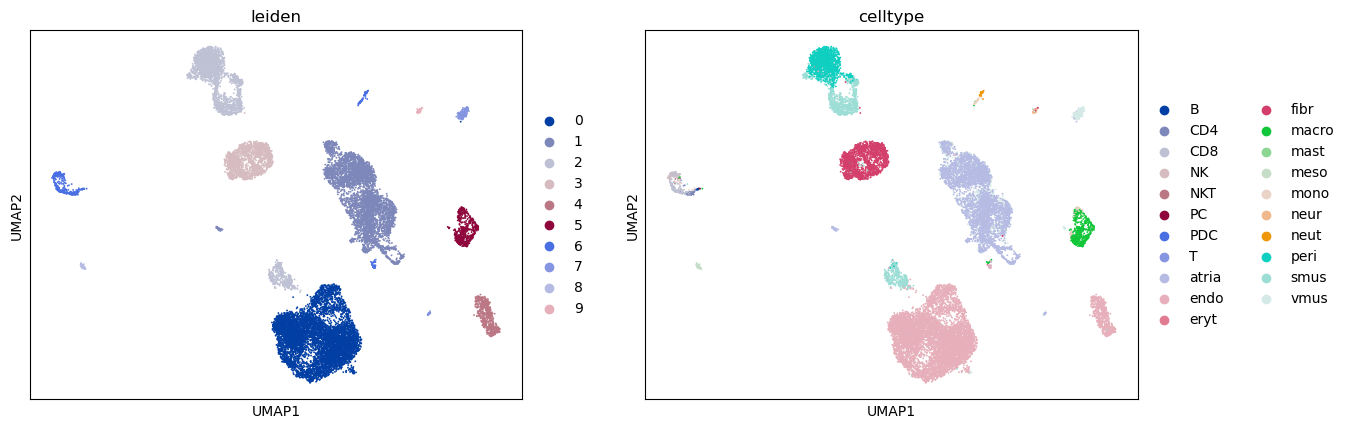

In [17]:
sc.pl.umap(adata,color = ["leiden","celltype"])

In [6]:
sklearn.metrics.adjusted_rand_score(adata.obs['celltype'], adata.obs['leiden'])

0.3575500778557416

Resolution is 0.1
creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

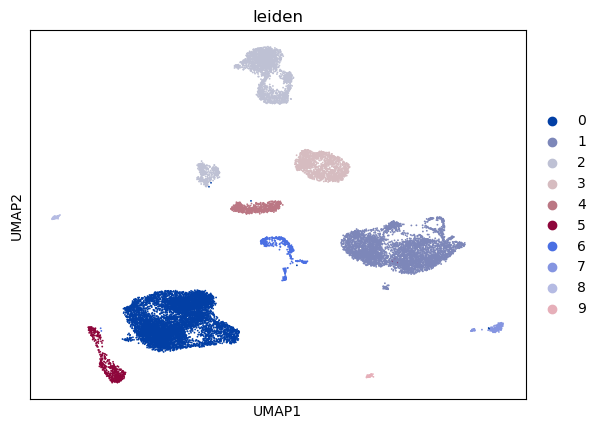

Resolution is 0.2
creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

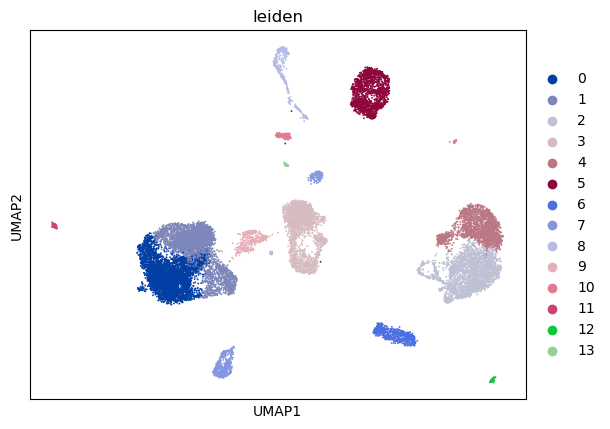

Resolution is 0.5
creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

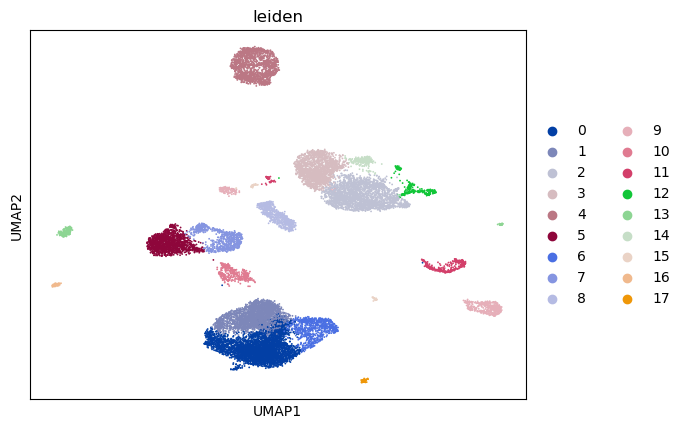

Resolution is 1.0
creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

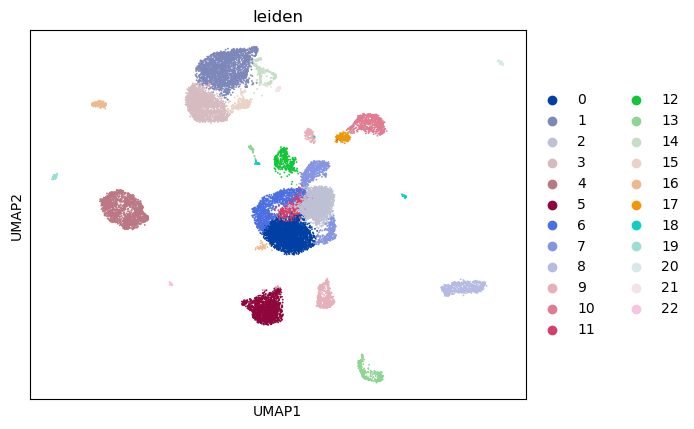

Resolution is 2
creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

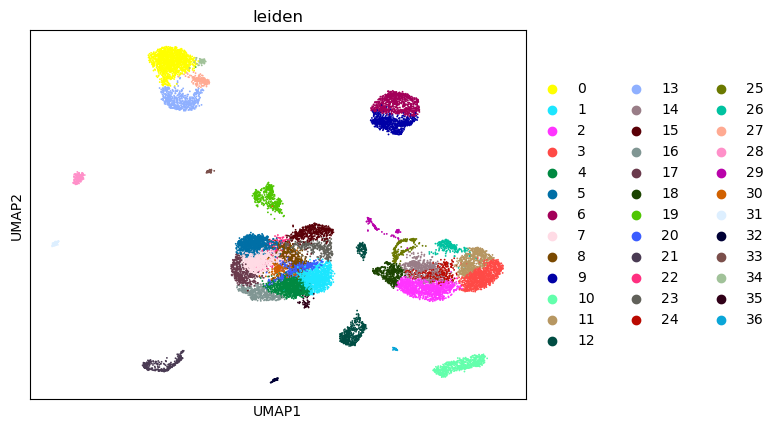

Resolution is 5
creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

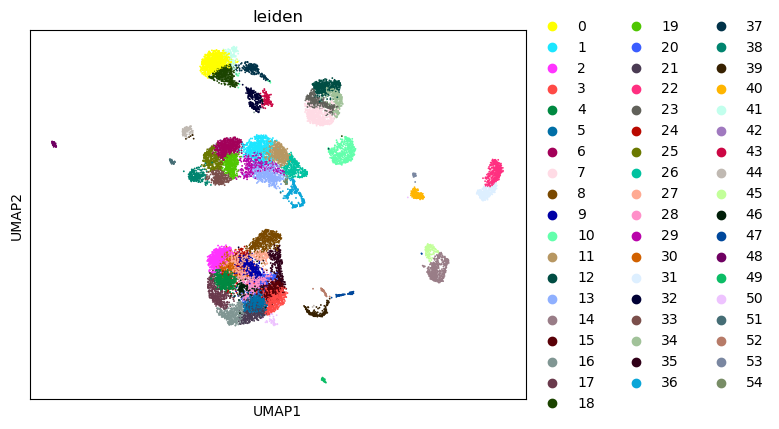

Resolution is 10
creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

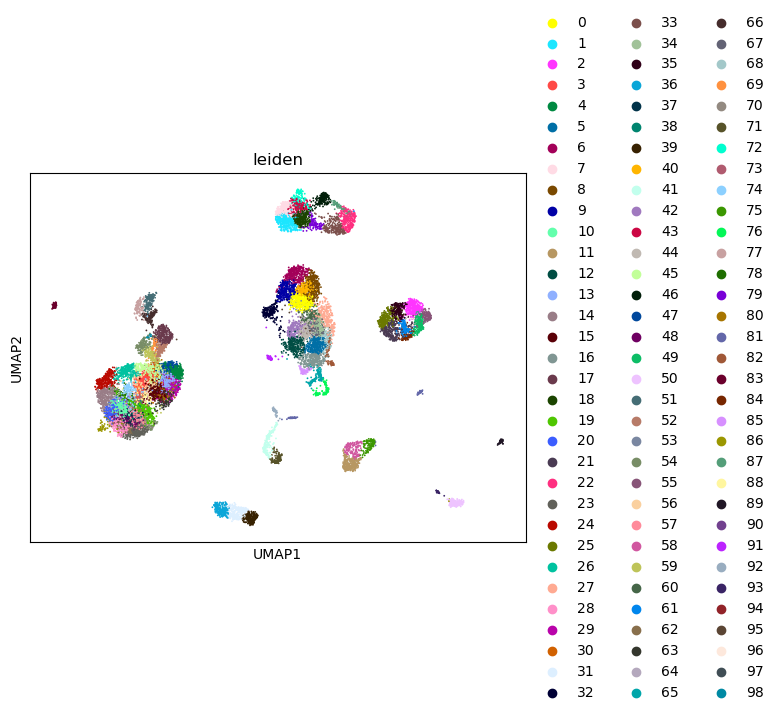

In [18]:
resolutions = [0.1,0.2,0.5,1.0,2,5,10]

ARI_scores = []
for resolution in resolutions:
    print(f"Resolution is {resolution}")
    util.pipeline(adata,k_nn=20,pca_dim = 50, resolution = resolution)
    ARI = sklearn.metrics.adjusted_rand_score(adata.obs['celltype'], adata.obs['leiden'])
    ARI_scores.append(ARI)

    sc.pl.umap(adata,color = ["leiden"])

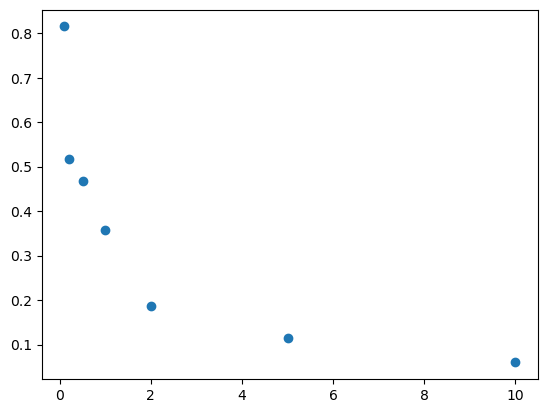

In [19]:
plt.scatter(resolutions, ARI_scores)

In [ ]:
df = manuscript_globalvslocal.create_gl_table("heart", type = "split",
                    min_cluster_size=500,
                    LRI_threshold=0.8,
                    tol=0.005,
                    overwrite=False)



creating table manuscript_data/globalvslocal/heart_LRI_globalvslocal.csv
Loading heart dataset
Computing heart global cutoffs
constructing cluster adjacency matrice
Computing heart local cutoffs
constructing cluster adjacency matrice


In [ ]:
#r0 should be the splitting resolutions, local or global
df

,dataset,cluster,local_r0,global_r0,cluster_frequency,n_partitions,LRI,min_freq
0,heart,0,0.104844,0.246094,0.402845,3,0.428927,0.109142
1,heart,1,0.046875,0.176719,0.253233,3,0.497650,0.011989
2,heart,2,0.021719,0.166094,0.140954,2,0.729532,0.161149
3,heart,3,0.126094,1.171094,0.091252,2,0.500011,0.487369
4,heart,4,0.109375,3.146094,0.035421,2,0.499932,0.480952
5,heart,5,0.078594,2.000000,0.030530,2,0.676323,0.202578


In [29]:
import util
import inspect

In [30]:
#I edited compute leiden and pipeline to allow custome leiden names
def compute_leiden(s, resolution=1,leiden_name = "leiden"):
    l = util.leiden(s.obsp["connectivities"], resolution=resolution)
    s.obs[leiden_name] = l

    return l


def pipeline(s, k_nn=20, pca_dim=50, resolution=1,leiden_name = "leiden"):
    util.scale(s)
    util.stabilize(s)
    print("creating embedding")
    util.embed(s, pca_dim=pca_dim)
    print("creating graph")
    util.form_graph(s, k_nn=k_nn)
    if resolution is not None:
        print("creating leiden")
        compute_leiden(s, resolution=resolution,leiden_name = leiden_name)
    print("creating umap")
    sc.tl.umap(s)

In [34]:
pipeline(adata,k_nn=20,pca_dim = 50, resolution = 0.1,leiden_name = "leiden")


creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

In [37]:
pipeline(adata,k_nn=20,pca_dim = 50, resolution = 1.18,leiden_name = "leiden_1.18")

creating embedding
creating graph
creating leiden
creating umap


/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:484: RuntimeWarning: divide by zero encountered in divide
  D = scipy.sparse.spdiags(1.0 / sqrt_deg, 0, graph.shape[0], graph.shape[0])
/home/dominic/anaconda3/envs/sc_clustering/lib/python3.12/site-packages/umap/spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some 

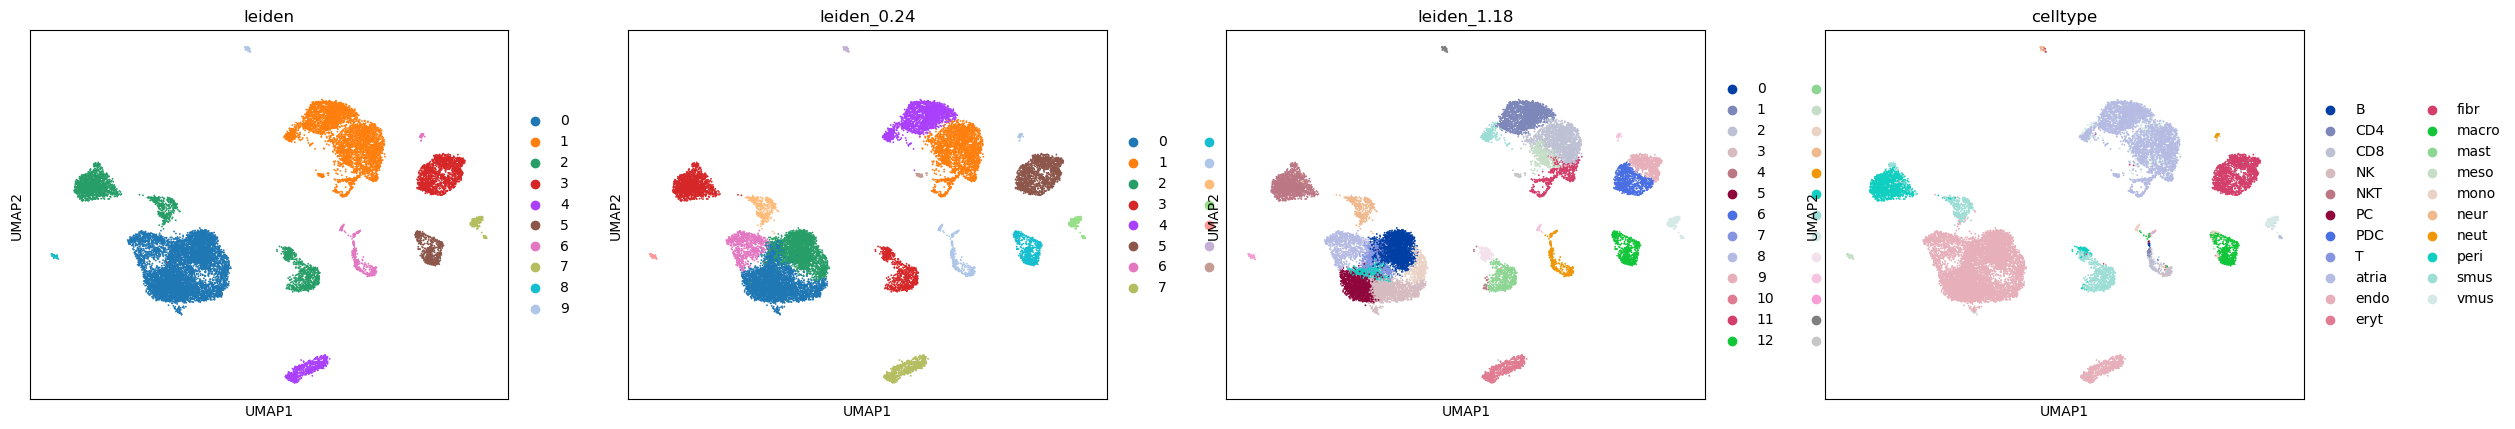

In [38]:
sc.pl.umap(adata,color = ["leiden","leiden_0.24","leiden_1.18","celltype"])

In [14]:
cutoffs = dataset_util.cutoffs(adata,adata.obs["leiden"], type = "global", min_cluster_size=500,
            k_nn=20, LRI_threshold=0.9, tol=0.02, debug=False)

constructing cluster adjacency matrice


In [15]:
cutoffs

,cluster,r0,cluster_frequency,LRI,n_partitions,min_freq,n
0,0,0.187500,1,0.871561,3,0.000140,7164
1,1,0.187500,1,0.496970,3,0.012013,4495
2,2,0.189375,1,0.734973,2,0.157160,2507
3,3,1.244375,1,0.509307,2,0.430684,1623
4,4,3.000000,1,0.507871,2,0.434231,631
5,5,2.434375,1,0.667429,2,0.210145,552
